In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader
from mediapipe_handcrop import MediapipeHandCrop2
import os
import cv2
from PIL import Image
import random
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from torchvision import models
from models import *
import torch.nn.functional as F


2025-02-17 22:21:31.742319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739827291.760591  311182 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739827291.766215  311182 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-17 22:21:31.784971: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.set_default_dtype(torch.float32)
    else:
        device = torch.device('cpu')
        torch.set_default_dtype(torch.float32)
    return device

device = setup_device()
print(f"Using {device} device")

# Set random seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using cuda device


## New Test Dataset

In [3]:
transform = transforms.Compose([
    MediapipeHandCrop2(), 
    transforms.Resize((64, 64)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


I0000 00:00:1739827293.895797  311182 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1739827293.933623  311355 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 3080/PCIe/SSE2


## Create DataFrame for new test dataset

In [4]:
# Directory containing the dataset
ROOT_DIR = "./asl_test_dataset"
CSV_FILE = "./asl_test_dataset/asl_dataset_csv.csv"

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [5]:
mediapipe_validator = MediapipeHandCrop2(include_characteristic_vectors=True)

data = []

for label in os.listdir(ROOT_DIR):
    label_dir = os.path.join(ROOT_DIR, label)
    
    if os.path.isdir(label_dir):
        for file_name in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file_name)

            # Validate image with Mediapipe and brightness
            try:
                result = mediapipe_validator(file_path)
                if result is None:
                    continue
                cropped_image, characteristic_vectors = result
            
            except Exception as e:
                    print(f"Error processing {file_path}: {e}")
                    continue
                
            data.append({"file_path": file_path, "file_name": file_name, "characteristic_vectors": characteristic_vectors, "label": label})

# Create a DataFrame
test_df = pd.DataFrame(data)

# Save DataFrame to CSV
test_df.to_csv(CSV_FILE, index=False)

print(f"CSV file saved at {CSV_FILE}")


I0000 00:00:1739827293.946444  311182 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1739827293.960519  311327 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1739827293.964474  311389 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 3080/PCIe/SSE2
W0000 00:00:1739827293.981074  311348 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1739827293.992011  311361 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1739827294.015060  311364 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:17

Error processing ./asl_test_dataset/.ipynb_checkpoints/asl_dataset_csv-checkpoint.csv: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

Error processing ./asl_test_dataset/B/.ipynb_checkpoints: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

Error processing ./asl_test_dataset/R/.ipynb_checkpoints: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

Error processing ./asl_test_dataset/Z/.ipynb_checkpoints: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'

CSV file saved at ./asl_test_dataset/asl_dataset_csv.csv


In [6]:
df = pd.read_csv(CSV_FILE)
print(f"{len(df) = }")
df.head()

len(df) = 328


,file_path,file_name,characteristic_vectors,label
0,./asl_test_dataset/W/Pasted image.png,Pasted image.png,"[[23.979832575871395, 64.38989042624449], [32....",W
1,./asl_test_dataset/W/3.png,3.png,"[[27.824517410792662, 64.5961179411813], [36.2...",W
2,./asl_test_dataset/W/Pasted image (3).png,Pasted image (3).png,"[[25.124452258601334, 64.28287783536044], [33....",W
3,./asl_test_dataset/W/w4.png,w4.png,"[[32.69065218193587, 64.00964550639308], [41.1...",W
4,./asl_test_dataset/W/Pasted image (2).png,Pasted image (2).png,"[[25.448539487777218, 64.47290728169102], [33....",W


In [7]:
import ast

class NewTestDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.csv_file = csv_file
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted([class_name for class_name in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, class_name))])

        # Maping class names to numbers 
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes) if os.path.isdir(os.path.join(self.root_dir, class_name))}

    def __len__(self):
        # Zsumuj liczbę plików w podkatalogach
        dataset_len = sum(
            len(os.listdir(os.path.join(self.root_dir, class_)))
            for class_ in self.classes
            if os.path.isdir(os.path.join(self.root_dir, class_))
        )
        return dataset_len
    
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("Index out of bounds")
        
        image_path = self.df.loc[idx, "file_path"]
        label = self.class_to_idx[self.df.loc[idx, 'label']]
        characteristic_vectors_str = self.df.loc[idx, "characteristic_vectors"]

        # Konwersja wektorów charakterystycznych
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)

                                                     
         # Loading image with cv2
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Transform
        if self.transform:
            image = self.transform(Image.fromarray(image))
        
        return image, label, characteristic_vectors
    

In [8]:
import os
import pandas as pd
import glob

def create_complete_csv(root_dir, output_csv):
    data = []
    
    # Walk through all directories
    for letter in sorted(os.listdir(root_dir)):
        if os.path.isdir(os.path.join(root_dir, letter)) and letter != 'asl-alphabet-test':
            letter_path = os.path.join(root_dir, letter)
            
            # Get all jpg files in the directory
            for img_file in glob.glob(os.path.join(letter_path, '*.jpg')):
                relative_path = os.path.relpath(img_file, root_dir)
                file_name = os.path.basename(img_file)
                
                # Create a row for each image
                data.append({
                    'file_path': relative_path,
                    'file_name': file_name,
                    'characteristic_vectors': '',  # You'll need to generate these
                    'label': letter
                })
    
    # Create DataFrame and save
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"Created CSV with {len(df)} entries")
    print(f"Classes found: {sorted(df['label'].unique())}")
    return df

# Create new CSV
ROOT_DIR = "./newest_dataset/validated_test"
NEW_CSV_FILE = "./newest_dataset/complete_test.csv"
df = create_complete_csv(ROOT_DIR, NEW_CSV_FILE)

Created CSV with 170 entries
Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [9]:
# import ast


# print("CSV file contents:")
# df = pd.read_csv(CSV_FILE)
# print("Number of rows:", len(df))
# print("\nFirst few rows:")
# print(df.head())


# transform = transforms.Compose([
#     transforms.Resize((64,64)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# def parse_vectors(vector_str):
#     cleaned_str = vector_str.replace('[', '').replace(']', '')
#     numbers = [float(x.strip().rstrip(',')) for x in cleaned_str.split() if x.strip()]
#     return np.array(numbers).reshape(-1, 2)

# class NewTestDataset(Dataset):
#     def __init__(self, root_dir, csv_file, transform=None):
#         self.root_dir = root_dir
#         self.csv_file = csv_file
#         self.transform = transform
#         self.df = pd.read_csv(self.csv_file)
#         self.classes = sorted(np.unique(self.df["label"]))
#         self.class_names = self.classes
    
#     def __len__(self):
#         return len(self.df)
    
#     def __getitem__(self, index):
#         if index >= len(self):
#             raise IndexError(f"Index {index} is out of bounds")
        
#         row = self.df.iloc[index]
#         label = row["label"]
#         file_path = row["file_path"]
        
#         # Fix path construction - remove any duplicate paths
#         clean_path = file_path.replace('./newest_dataset/validated_test/', '')
#         # clean_path = clean_path.replace('newest_dataset/validated_test/', '')
#         image_path = os.path.join(self.root_dir, clean_path)
        
#         print(f"Loading image from: {image_path}")  # Debug print
        
#         image = cv2.imread(image_path)
#         if image is None:
#             raise FileNotFoundError(f"Image not found: {image_path}")
        
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#         if self.transform:
#             image = self.transform(Image.fromarray(image))
            
#         characteristic_vectors = parse_vectors(row["characteristic_vectors"])
        
#         original_height, original_width = 64, 64
#         characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
#         characteristic_vectors[:, 1] *= (image.shape[1] / original_height)
        
#         return image, label, characteristic_vectors

In [10]:
# # Print CSV info
# print("CSV Contents:")
# df = pd.read_csv(CSV_FILE)
# print("\nTotal rows:", len(df))
# print("\nUnique labels:", sorted(df['label'].unique()))
# print("\nSample rows:")
# print(df.head())

# # Print directory structure
# print("\nDirectory Contents:")
# print("Available directories in", ROOT_DIR)
# print(os.listdir(ROOT_DIR))

# # Print class distribution
# print("\nClass distribution in CSV:")
# print(df['label'].value_counts())

In [11]:
# Train dataset and dataloader initialization
new_test_dataset = NewTestDataset(root_dir=ROOT_DIR, 
                        csv_file=CSV_FILE, 
                        transform=transform,
                        )

In [12]:
new_test_dataset.classes

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

## Sanity check

Dataset len:
175

Dataset classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Random image from dataset:

Image size:
(64, 64, 3)


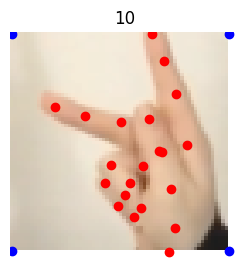

Characteristic vectors: 
[[46.14755    64.21815   ]
 [48.03997    57.098347  ]
 [46.973724   45.70119   ]
 [43.410664   34.642944  ]
 [40.501724   25.230362  ]
 [51.644318   32.8375    ]
 [48.24916    17.68476   ]
 [44.76737     7.9126863 ]
 [41.201218    0.06799316]
 [44.193523   34.692024  ]
 [32.272896   26.009245  ]
 [21.481983   24.094072  ]
 [12.800865   21.67011   ]
 [38.499012   38.79275   ]
 [29.0851     38.51211   ]
 [33.467007   47.31943   ]
 [38.006298   51.131687  ]
 [34.853077   43.831394  ]
 [27.40029    43.894264  ]
 [31.388142   50.74626   ]
 [35.962734   53.81348   ]]


In [13]:
# Sanity check
print("Dataset len:")
print(len(new_test_dataset))

print("\nDataset classes:")
print(new_test_dataset.classes)

print("\nRandom image from dataset:")
image, label, characteristic_vectors = new_test_dataset[random.randint(0, len(new_test_dataset)-1)]
image = image.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

print('\nImage size:')
print(image.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, image.shape[0], image.shape[1]], [0, image.shape[1], image.shape[1], 0], c="blue")  

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


Dataset len:
175

Dataset classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Random images from dataset:


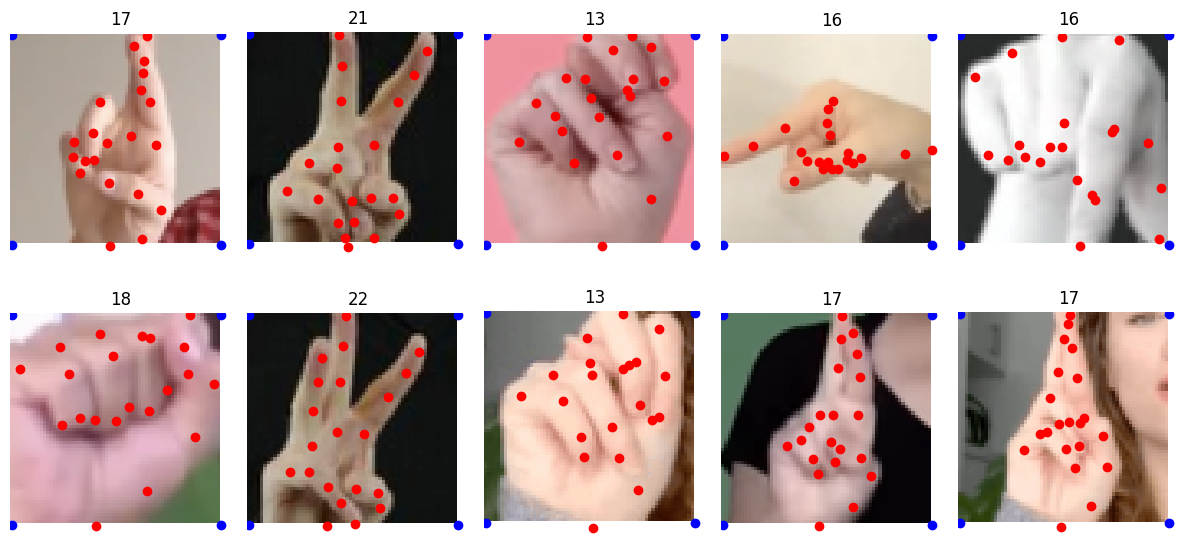

In [14]:
# Sanity check
print("Dataset len:")
print(len(new_test_dataset))

print("\nDataset classes:")
print(new_test_dataset.classes)

print("\nRandom images from dataset:")

plt.figure(figsize=(12,6))
for i in range(10):
    # Fetch image
    image, label, characteristic_vectors = new_test_dataset[random.randint(0, len(new_test_dataset)-1)]
    
    image = image.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
    
    # Denormalizing (there was normalization in transform)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image = image * std + mean
    image = image.clip(0, 1)

    # Ploting
    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
    plt.scatter([0, 0, image.shape[0], image.shape[1]], [0, image.shape[1], image.shape[0], 0], c="blue")  
    plt.axis("off")
    plt.title(label)
    

plt.tight_layout()
plt.show()

# MODEL TESTING

In [15]:
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    print(f"Using {model.__class__}")
     
    with torch.inference_mode():
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)

            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)
            
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    return test_loss, test_accuracy

In [16]:
test_dataloader = DataLoader(new_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)

In [17]:
def visualize_predictions(model, test_loader, device, criterion, num_images=20):
    model.eval()
    predictions = []
    true_labels = []

    print(f"Using {model.__class__}")
    
    with torch.inference_mode():
        for images, labels, characteristic_vectors in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            characteristic_vectors = characteristic_vectors.to(device)
            
            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)

            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)
            
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    plt.figure(figsize=(15, 6))
    num_images = min(num_images, len(predictions))
    indices = random.sample(range(len(predictions)), num_images)
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, idx in enumerate(indices):
        image, label, _ = test_loader.dataset[idx]  # Correct unpacking
        image = image.permute(1, 2, 0).numpy()
        
        # Denormalize image
        image = image * std + mean
        image = np.clip(image, 0, 1)
        
        plt.subplot(4, num_images//4, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f'Pred: {predictions[idx]}, True: {label}')
    
    plt.tight_layout()
    plt.show()

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_softmax(device, model, test_loader, class_names):
    model.eval()

    print(f"Using {model.__class__}")

    labels_ = []
     
    with torch.inference_mode():
        for images, labels, characteristic_vectors in test_loader:
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)

            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)
            labels_.append(labels)

    for i in range(5):
        output = outputs[i]
        label - labels_[i]

        # Compute softmax probabilities
        probabilities = F.softmax(output, dim=0) 
        predicted_index = probabilities.argmax(dim=0).item() 
        
        # Format probabilities to avoid scientific notation and create a dict
        formatted_probabilities = {class_names[j]: float(f"{prob:.4f}") for j, prob in enumerate(probabilities.cpu().numpy())}

        # Get the true andpredicted class
        true_class = class_names[label]
        predicted_class = class_names[predicted_index]
        
        # Print results to console
        print(f"True class: {label}")
        print(f"Predicted class: {predicted_class}")
        print(f"Class probabilities: {formatted_probabilities}\n")
        
        # Convert image to numpy for visualization
        image_np = images[i].cpu().permute(1, 2, 0).numpy()  # Change shape from (C, H, W) to (H, W, C)

        plt.figure(figsize=(4, 4))
        image = image_np * std + mean
        image = np.clip(image, 0, 1)

        plt.imshow(image)
        plt.axis('off')
        plt.title(f"True class: {true_class}\nPredicted class: {predicted_class}")
        plt.show() 


# BASE MODEL

In [19]:
num_classes=len(new_test_dataset.classes)
model = BaseModel(num_classes)
# model = torch.load(r".\models\base_model\base_model")
model = torch.load(r"./models/base_model")
model.to(device)

/home/oobx/Desktop/PROJEKTY/SIiUM/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/oobx/Desktop/PROJEKTY/SIiUM/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_311182/3476444771.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pyto

BaseModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

### ACCURACY

In [20]:
# criterion = nn.CrossEntropyLoss()
# test_model(device, model, test_dataloader, criterion)

In [21]:
criterion = nn.CrossEntropyLoss()
test_model(device, model, test_dataloader, criterion)

Using <class 'models.BaseModel'>
Test Loss: 0.1209, Test Accuracy: 35.43%


(0.12088131087166923, 35.42857142857143)

### PREDICTIONS VISUALIZATION

Using <class 'models.BaseModel'>


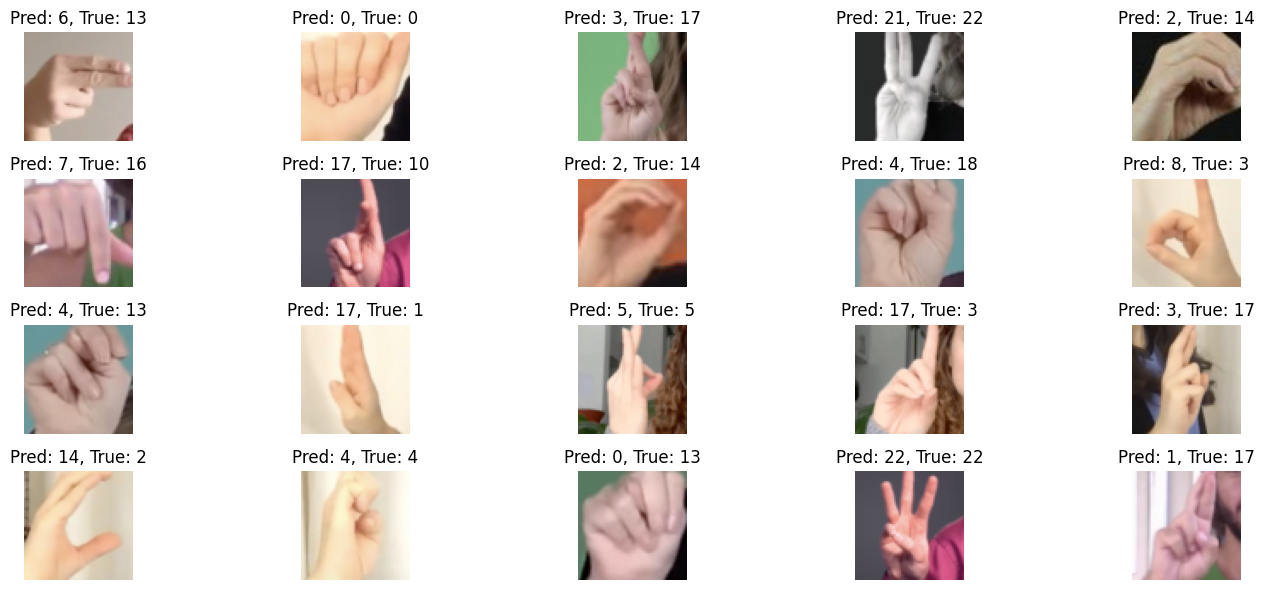

In [22]:
visualize_predictions(model, test_dataloader, device, criterion)

### SOFTMAX VISUALIZATION

Using <class 'models.BaseModel'>
True class: 17
Predicted class: N
Class probabilities: {'A': 0.0135, 'B': 0.0071, 'C': 0.1681, 'D': 0.0002, 'E': 0.0503, 'F': 0.0015, 'G': 0.0005, 'H': 0.0025, 'I': 0.0025, 'J': 0.0008, 'K': 0.0002, 'L': 0.0008, 'M': 0.0181, 'N': 0.6323, 'O': 0.0049, 'P': 0.0001, 'Q': 0.0002, 'R': 0.0004, 'S': 0.0311, 'T': 0.0259, 'U': 0.0016, 'V': 0.0001, 'W': 0.0005, 'X': 0.0315, 'Y': 0.005, 'Z': 0.0003}



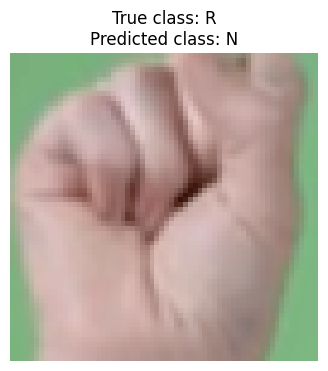

True class: 17
Predicted class: N
Class probabilities: {'A': 0.0026, 'B': 0.0242, 'C': 0.0003, 'D': 0.0001, 'E': 0.0615, 'F': 0.0009, 'G': 0.0012, 'H': 0.007, 'I': 0.0053, 'J': 0.0004, 'K': 0.0002, 'L': 0.0001, 'M': 0.1592, 'N': 0.6362, 'O': 0.0012, 'P': 0.0, 'Q': 0.0001, 'R': 0.0003, 'S': 0.0456, 'T': 0.0217, 'U': 0.0007, 'V': 0.0007, 'W': 0.016, 'X': 0.0093, 'Y': 0.0052, 'Z': 0.0001}



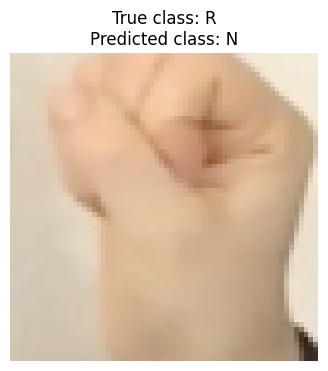

True class: 17
Predicted class: D
Class probabilities: {'A': 0.0004, 'B': 0.0008, 'C': 0.0898, 'D': 0.48, 'E': 0.0154, 'F': 0.1265, 'G': 0.0041, 'H': 0.0058, 'I': 0.0408, 'J': 0.001, 'K': 0.0024, 'L': 0.001, 'M': 0.0023, 'N': 0.1777, 'O': 0.0025, 'P': 0.0072, 'Q': 0.0141, 'R': 0.0035, 'S': 0.0017, 'T': 0.0002, 'U': 0.001, 'V': 0.0009, 'W': 0.0012, 'X': 0.0142, 'Y': 0.004, 'Z': 0.0013}



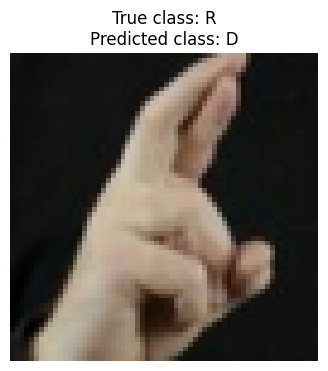

True class: 17
Predicted class: J
Class probabilities: {'A': 0.0001, 'B': 0.0018, 'C': 0.0002, 'D': 0.0008, 'E': 0.0003, 'F': 0.0105, 'G': 0.0001, 'H': 0.0001, 'I': 0.0109, 'J': 0.9383, 'K': 0.0025, 'L': 0.0001, 'M': 0.0, 'N': 0.0003, 'O': 0.0009, 'P': 0.0004, 'Q': 0.0001, 'R': 0.012, 'S': 0.0008, 'T': 0.0003, 'U': 0.0001, 'V': 0.0001, 'W': 0.0002, 'X': 0.0152, 'Y': 0.0026, 'Z': 0.0009}



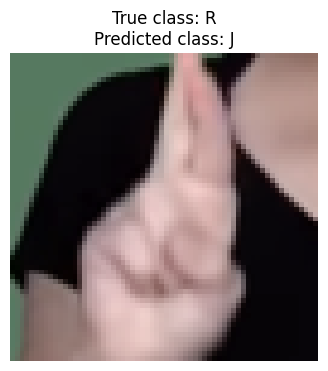

True class: 17
Predicted class: R
Class probabilities: {'A': 0.0, 'B': 0.0007, 'C': 0.0002, 'D': 0.0102, 'E': 0.0, 'F': 0.0009, 'G': 0.0002, 'H': 0.0001, 'I': 0.0022, 'J': 0.0206, 'K': 0.0277, 'L': 0.0004, 'M': 0.0, 'N': 0.0, 'O': 0.0002, 'P': 0.0001, 'Q': 0.0, 'R': 0.8299, 'S': 0.0, 'T': 0.0001, 'U': 0.0026, 'V': 0.0965, 'W': 0.0028, 'X': 0.0007, 'Y': 0.0026, 'Z': 0.0011}



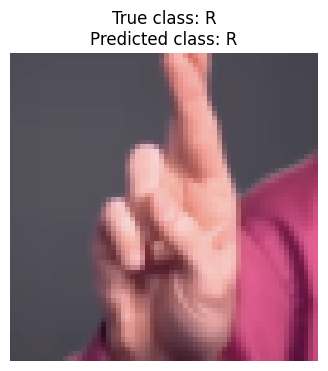

In [23]:
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
visualize_softmax(device, model, test_dataloader, class_names)  

### CONFUSION MATRIX

In [24]:
#TODO confusion matrix for base model

# MULTIMODAL MODEL


In [25]:
num_classes = len(new_test_dataset.classes)
model = MultimodalModel(num_classes, num_landmarks=21)
model = torch.load(r"./models/multimodal/model epoch 15")
model.to(device)

/tmp/ipykernel_311182/3689013003.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(r"./models/multimodal/model epoch 15")


MultimodalModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

### TESTING

In [26]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = test_model(device, model, test_dataloader, criterion)

Using <class 'models.MultimodalModel'>
Test Loss: 0.0233, Test Accuracy: 81.71%


### PREDICTIONS VISUALIZATION

Using <class 'models.MultimodalModel'>


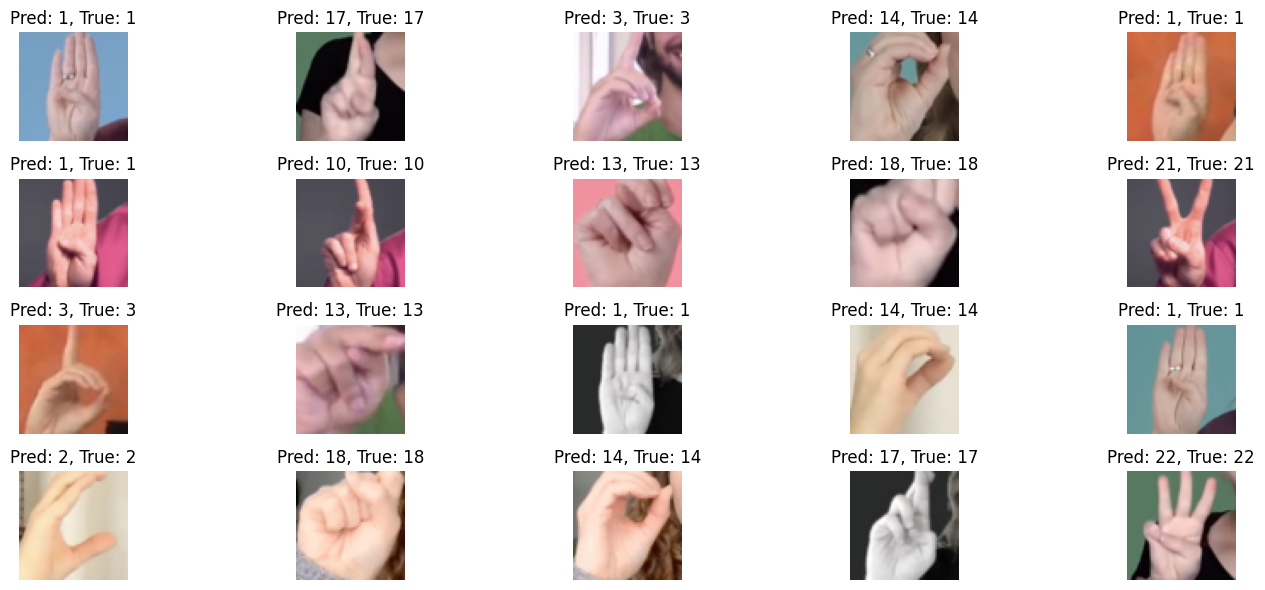

In [27]:
visualize_predictions(model, test_dataloader, device, criterion)

### SOFTMAX VISUALIZATION

Using <class 'models.MultimodalModel'>
True class: 17
Predicted class: N
Class probabilities: {'A': 0.0046, 'B': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0003, 'F': 0.0, 'G': 0.0001, 'H': 0.0001, 'I': 0.0002, 'J': 0.0, 'K': 0.0004, 'L': 0.0, 'M': 0.0008, 'N': 0.8455, 'O': 0.0, 'P': 0.0, 'Q': 0.0, 'R': 0.0, 'S': 0.126, 'T': 0.0215, 'U': 0.0001, 'V': 0.0, 'W': 0.0, 'X': 0.0, 'Y': 0.0, 'Z': 0.0001}



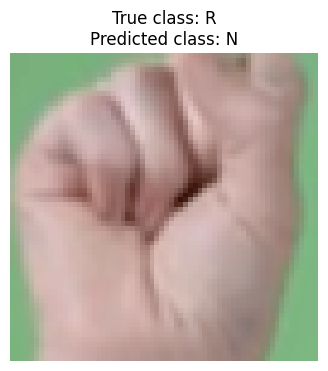

True class: 17
Predicted class: E
Class probabilities: {'A': 0.0005, 'B': 0.0004, 'C': 0.0, 'D': 0.0002, 'E': 0.5643, 'F': 0.0007, 'G': 0.0, 'H': 0.0028, 'I': 0.0043, 'J': 0.0001, 'K': 0.0004, 'L': 0.0, 'M': 0.2674, 'N': 0.0179, 'O': 0.0005, 'P': 0.0, 'Q': 0.0, 'R': 0.0005, 'S': 0.1375, 'T': 0.0013, 'U': 0.0005, 'V': 0.0002, 'W': 0.0003, 'X': 0.0001, 'Y': 0.0, 'Z': 0.0}



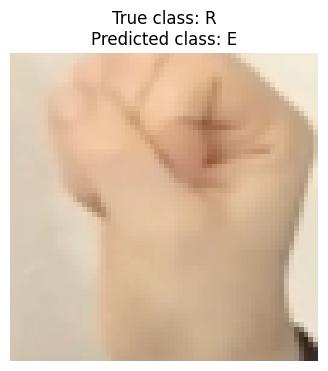

True class: 17
Predicted class: R
Class probabilities: {'A': 0.0, 'B': 0.0, 'C': 0.003, 'D': 0.0498, 'E': 0.0, 'F': 0.0002, 'G': 0.0001, 'H': 0.0, 'I': 0.0, 'J': 0.0001, 'K': 0.0005, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0001, 'Q': 0.0002, 'R': 0.9427, 'S': 0.0, 'T': 0.0, 'U': 0.0007, 'V': 0.0015, 'W': 0.0005, 'X': 0.0002, 'Y': 0.0, 'Z': 0.0}



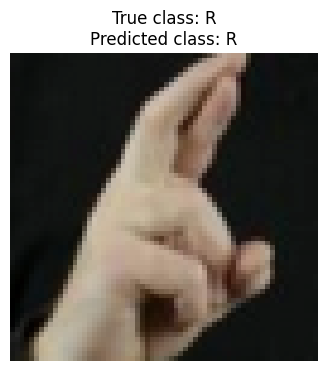

True class: 17
Predicted class: R
Class probabilities: {'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'J': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0, 'Q': 0.0001, 'R': 0.8332, 'S': 0.0, 'T': 0.0, 'U': 0.1648, 'V': 0.0017, 'W': 0.0001, 'X': 0.0, 'Y': 0.0, 'Z': 0.0}



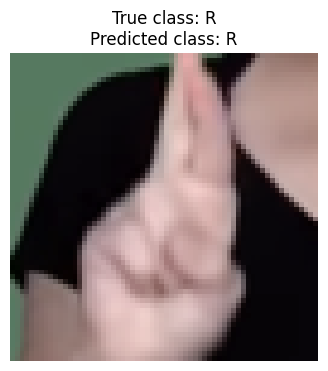

True class: 17
Predicted class: R
Class probabilities: {'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'J': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0, 'Q': 0.0, 'R': 0.9999, 'S': 0.0, 'T': 0.0, 'U': 0.0, 'V': 0.0, 'W': 0.0, 'X': 0.0, 'Y': 0.0, 'Z': 0.0}



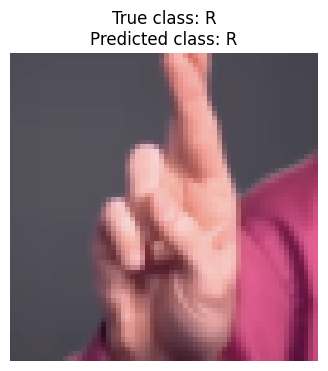

In [28]:
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
visualize_softmax(device, model, test_dataloader, class_names)  

### CONFUSION MATRIX

In [29]:
#TODO confusion matrix for multimodal model

In [30]:
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    num_classes = len(test_loader.dataset.classes)
    print('num_classes: ', num_classes)
    confusion_matrix = torch.zeros(num_classes, num_classes)
    
    with torch.inference_mode():
        # for images, labels, characteristic_vectors in test_loader:
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            inputs = images.to(device)
            labels = labels.to(device)
            characteristic_vectors = characteristic_vectors.to(device)
            
            outputs = model(inputs, characteristic_vectors)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
    
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct / total
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
    
    print("\nPer-class accuracy:")
    class_names = test_loader.dataset.classes
    for i in range(num_classes):
        class_accuracy = 100 * confusion_matrix[i, i] / confusion_matrix[i].sum()
        print(f'Class {class_names[i]}: {class_accuracy:.2f}%')
        # experiment.log_metric(f"class_{class_names[i]}_accuracy", class_accuracy)
    
    return test_loss, test_accuracy, confusion_matrix


num_classes=len(new_test_dataset.classes)
model = MultimodalModel(num_classes, num_landmarks=21)
model = torch.load(r"./models/multimodal/model epoch 15")
model.to(device)


ROOT_DIR = "./asl_test_dataset"
CSV_FILE = "./asl_test_dataset/asl_dataset_csv.csv"


new_test_dataset = NewTestDataset(root_dir=ROOT_DIR, 
                        csv_file=CSV_FILE, 
                        transform=transform,
                        )


test_dataloader = DataLoader(new_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)


test_loss, test_accuracy, confusion_matrix = test_model(
    device=device,
    model=model,
    test_loader=test_dataloader,
    criterion=criterion
)


/tmp/ipykernel_311182/3126414929.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(r"./models/multimodal/model epoch 15")


num_classes:  27


../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [26,0,0] Assertion `t >= 0 && t < n_classes` failed.
../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [27,0,0] Assertion `t >= 0 && t < n_classes` failed.
../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [28,0,0] Assertion `t >= 0 && t < n_classes` failed.
../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [29,0,0] Assertion `t >= 0 && t < n_classes` failed.
../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [30,0,0] Assertion `t >= 0 && t < n_classes` failed.
../aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [31,0,0] Assertion `t >= 0 && t < n_classes` failed.


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:

def plot_confusion_matrix(confusion_matrix, class_names):
    cm_percent = confusion_matrix.numpy()
    cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(15, 15))

    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues',
                vmin=0,
                vmax=100)
    
    plt.title('Confusion Matrix (%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    
    plt.savefig('confusion_matrix.png')
    plt.show()

    print("\nMost confused pairs (True -> Predicted):")
    n_classes = len(class_names)
    confused_pairs = []
    
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j and cm_percent[i, j] > 1:  # More than 1% confusion
                confused_pairs.append((
                    class_names[i], 
                    class_names[j], 
                    cm_percent[i, j]
                ))
    
    confused_pairs.sort(key=lambda x: x[2], reverse=True)
    
    for true_class, pred_class, percent in confused_pairs[:10]:
        print(f"{true_class} -> {pred_class}: {percent:.1f}%")

class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
plot_confusion_matrix(confusion_matrix, class_names)



In [ ]:
def predict_image(image_path, model, device, class_names):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.to(device)

    model.eval()
    with torch.inference_mode():
        outputs = model(image_tensor) 
        probabilities = F.softmax(outputs, dim=1) 
        predicted_index = probabilities.argmax(dim=1).item() 

    formatted_probabilities = [float(f"{p:.4f}") for p in probabilities[0].cpu().numpy()]

    predicted_class = class_names[predicted_index]
    return predicted_class, formatted_probabilities

# Example usage
# image_path = "./dataset/asl_alphabet_test/N_test.jpg"
image_path = "./dataset/asl_test_dataset/N/N0004_test.jpg"
class_names = new_test_dataset.classes
predicted_class, probabilities = predict_image(image_path, model, device, class_names)

print(f"Predicted class: {predicted_class}")
print(f"Class probabilities: {probabilities}")


In [ ]:
pwd